In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset,random_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert torch.cuda.is_available(), "CUDA NOT AVAILABLE — GPU CANNOT BE USED"

device = torch.device("cuda:1")  
print("Using GPU:", torch.cuda.get_device_name(1))

Using GPU: NVIDIA L4


In [ ]:
train_transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),
])

trainset_aug = datasets.CIFAR10(
    root="/DATA/suraj/pr1/datasets/aug",
    train=True,
    download=True,
    transform=train_transform_aug
)

testset = datasets.CIFAR10(
    root="/DATA/suraj/pr1/datasets",
    train=False,
    download=True,
    transform=train_transform_aug
)

In [5]:
x_train, x_test = train_test_split(
    trainset_aug, test_size=0.2, random_state=42, shuffle=True
)

In [11]:
test_loader = DataLoader(testset, batch_size=128)

In [6]:
train_loader = DataLoader(trainset_aug, batch_size=128, shuffle=True)
val_loader = DataLoader(x_test, batch_size=128)
test_loader = DataLoader(testset, batch_size=128)


In [6]:
model = models.resnet18(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Training accuracy vs epochs

Validation accuracy vs epochs

Training loss vs epochs

Validation loss vs epochs

Final test accuracy

In [13]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

num_epochs = 10

for epoch in range(num_epochs):
    # -------- TRAIN --------
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # -------- VALIDATION --------
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )


Epoch [1/10] | Train Loss: 1.6370, Train Acc: 0.4014 | Val Loss: 1.6243, Val Acc: 0.4239
Epoch [2/10] | Train Loss: 1.3158, Train Acc: 0.5249 | Val Loss: 1.5824, Val Acc: 0.4453
Epoch [3/10] | Train Loss: 1.1667, Train Acc: 0.5863 | Val Loss: 1.1800, Val Acc: 0.5799
Epoch [4/10] | Train Loss: 1.0611, Train Acc: 0.6238 | Val Loss: 1.0766, Val Acc: 0.6182
Epoch [5/10] | Train Loss: 0.9906, Train Acc: 0.6512 | Val Loss: 1.0331, Val Acc: 0.6341
Epoch [6/10] | Train Loss: 0.9289, Train Acc: 0.6737 | Val Loss: 0.9255, Val Acc: 0.6745
Epoch [7/10] | Train Loss: 0.8821, Train Acc: 0.6903 | Val Loss: 1.0182, Val Acc: 0.6433
Epoch [8/10] | Train Loss: 0.8447, Train Acc: 0.7028 | Val Loss: 0.8854, Val Acc: 0.6901
Epoch [9/10] | Train Loss: 0.8039, Train Acc: 0.7198 | Val Loss: 0.9610, Val Acc: 0.6626
Epoch [10/10] | Train Loss: 0.7852, Train Acc: 0.7283 | Val Loss: 1.1095, Val Acc: 0.6336


In [14]:
import os

os.makedirs("checkpoints", exist_ok=True)

MODEL_PATH = "checkpoints/resnet18_cifar10_augmented_2.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": num_epochs
}, MODEL_PATH)

print(f"Model saved at {MODEL_PATH}")


Model saved at checkpoints/resnet18_cifar10_augmented_2.pth


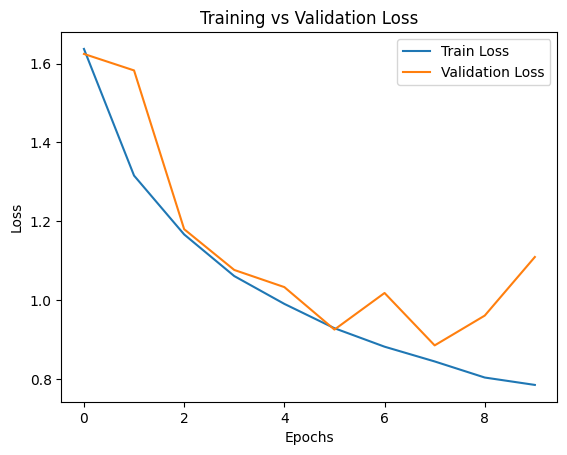

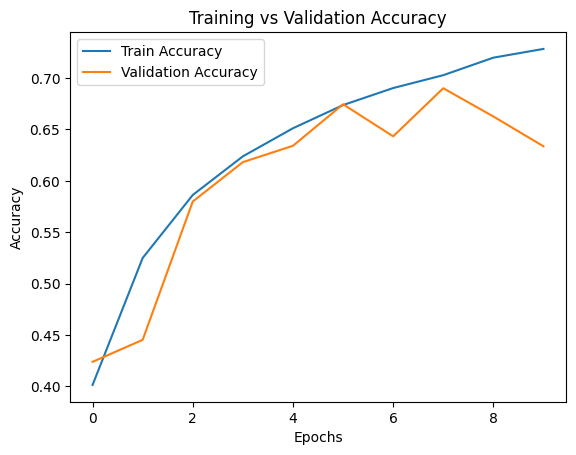

In [15]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


In [ ]:
MODEL_PATH = "checkpoints/resnet18_cifar10_augmented_2.pth"



checkpoint = torch.load(MODEL_PATH, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
l2_model = model.eval()  

print("Model loaded successfully")


Model loaded successfully


In [14]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Final Test Accuracy: {test_accuracy:.4f}")


Final Test Accuracy: 0.6149


In [13]:
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"]

In [9]:
failure_cases = torch.load("/DATA/suraj/pr1/.venv/try2/failure_cases_baseline_2.pt")

In [22]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import cv2
import os

os.makedirs("gradcam_augmented_2", exist_ok=True)

cam_aug = GradCAM(
    model=model,
    target_layers=[model.layer4[-1]],
    
)

for i, case in enumerate(failure_cases[:20]):
    input_tensor = case["image"].unsqueeze(0).float().to(device)
    targets = [ClassifierOutputTarget(case["pred"])]

    grayscale_cam = cam_aug(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    rgb_img = case["image"].permute(1, 2, 0).cpu().numpy()
    rgb_img = np.clip(rgb_img, 0, 1)

    cam_image = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    cv2.imwrite(
        f"gradcam_augmented_2/failure_{i}.png",
        cv2.cvtColor(cam_image, cv2.COLOR_RGB2BGR)
    )

    print(
        f"Grad-CAM saved | "
        f"T={case['true']} P={case['pred']} Conf={case['conf']:.2f}"
    )


Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=2 P=6 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=0 P=9 Conf=1.00
Grad-CAM saved | T=3 P=6 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=3 P=6 Conf=1.00
Grad-CAM saved | T=2 P=6 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=0 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00


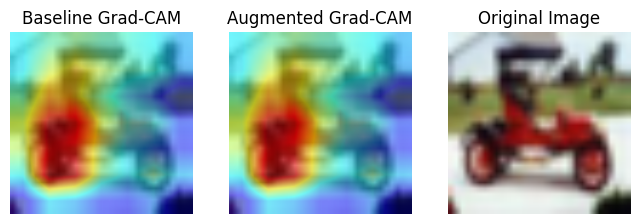

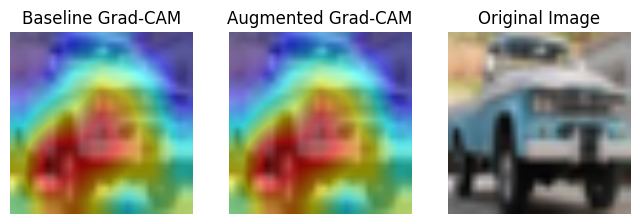

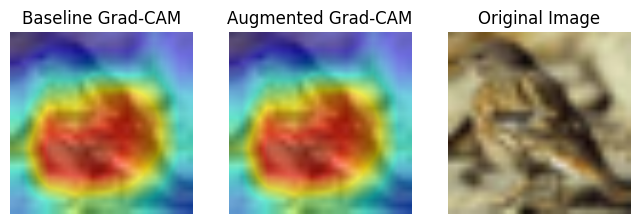

In [26]:
import matplotlib.pyplot as plt
from PIL import Image

for i in range(3):
    fig, axs = plt.subplots(1, 3, figsize=(8, 4))

    
    axs[0].imshow(Image.open(f"gradcam/failure_{i}.png"))
    axs[0].set_title("Baseline Grad-CAM")
    axs[0].axis("off")

    axs[1].imshow(Image.open(f"gradcam_augmented_2/failure_{i}.png"))
    axs[1].set_title("Augmented Grad-CAM")
    axs[1].axis("off")
    
    axs[2].imshow(Image.open(f"failure_cases_2/failure_{i}.png"))
    axs[2].set_title("Original Image")
    axs[2].axis("off") 
    plt.show()
